In [2]:
# importing necessary libraries

import numpy as np
import pandas as pd 
import os 
import json 
import joblib

#Importing Logistic regression classifier , RandomForest Classifier , XGBoost classifier , 
#Importing the classificatoin metrics : Accuracy , precision , recall , auc , auc-roc , classification report , confusion matrix
# 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score

import warnings 
warnings.filterwarnings('ignore')

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input , Dense , Dropout , BatchNormalization ,Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
# import tensorflow_addons as tfa  # not working for this python version 

In [4]:
X_train=pd.read_csv("../data/processed/train_val_test/X_train.csv")
X_val=pd.read_csv("../data/processed/train_val_test/X_val.csv")
X_test=pd.read_csv("../data/processed/train_val_test/X_test.csv")
y_train=np.load("../data/processed/train_val_test/y_train.npy")
y_test=np.load("../data/processed/train_val_test/y_test.npy")
y_val=np.load("../data/processed/train_val_test/y_val.npy")
X_train_smote=np.load("../data/processed/train_val_test/X_train_smote.npy")
X_train_smote_tomek=np.load("../data/processed/train_val_test/X_train_smote_tomek.npy")
y_train_smote = np.load("../data/processed/train_val_test/y_train_smote.npy")
y_train_smote_tomek = np.load("../data/processed/train_val_test/y_train_smote_tomek.npy")


In [5]:
# Metric Evaluation function for classification models

def evaluate(model, X_train, y_train, X_val, y_val):
    # Checking the training accuracy
    train_accuracy = model.score(X_train, y_train)
    print(f"Training accuracy: {train_accuracy}")
    # Checking the validation accuracy
    val_accuracy = model.score(X_val, y_val)
    print(f"Validation accuracy: {val_accuracy}")

    # Getting predictions
    ypred_train = model.predict(X_train)
    ypred_val = model.predict(X_val)

    # Precision, Recall, F1-Score
    print("The precision score tells the model performance in handling False Positive Cases (FP).Higher the precision_score , lower is the False positives occurences by the model.")
    print("Training precision:", precision_score(y_train, ypred_train, average=None))
    print("Validation precision:", precision_score(y_val, ypred_val, average=None))

    print("The recall score tells the model performance in handling False Negative cases(FN). Higher the recall score , lower is the FN occurences by the model")
    print("Training recall:", recall_score(y_train, ypred_train, average=None))
    print("Validation recall:", recall_score(y_val, ypred_val, average=None))

    print("F1 score is the harmonic mean of the precision and recall.Range 0 to 1 .The higher , the better.")
    print("Training F1-score:", f1_score(y_train, ypred_train, average=None))
    print("Validation F1-score:", f1_score(y_val, ypred_val, average=None))

    # Confusion matrix
    print("Training confusion matrix:")
    print(confusion_matrix(y_train, ypred_train))
    print("Validation confusion matrix:")
    print(confusion_matrix(y_val, ypred_val))

    # Classification report
    print("Training classification report:")
    print(classification_report(y_train, ypred_train))
    print("Validation classification report:")
    print(classification_report(y_val, ypred_val))

Choosing the evaluation metric for model_selection : 
For this classification problem both precision and recall seems to be equally important . Precision represents the model's performance in the prediction of positive class keeping in mind the FP rate(incorrectly predicting as positive class) , while recall also represents model's performance keeping in mind the FN(incorrectly predicting as negative class).Both seems to be important metrics here for the multiclass classification problem . Therfore : We chose F1_score : i.e the harmonic mean of precision and recall as the main evaluation metric

In [6]:
# Logistic regression

lr = LogisticRegression(multi_class='multinomial', solver='saga', class_weight='balanced')
lr.fit(X_train, y_train)
evaluate(lr, X_train, y_train, X_val, y_val)

# lr1 = LogisticRegression(multi_class='multinomial', solver='saga', class_weight='balanced')
# lr1.fit(X_train_smote, y_train_smote)
# evaluate(lr1, X_train_smote, y_train_smote, X_val, y_val)

# lr2 = LogisticRegression(multi_class='multinomial', solver='saga', class_weight='balanced')
# lr2.fit(X_train_smote_tomek, y_train_smote_tomek)
# evaluate(lr2, X_train_smote_tomek, y_train_smote_tomek, X_val, y_val)

Training accuracy: 0.36809021462349945
Validation accuracy: 0.37166802467698756
The precision score tells the model performance in handling False Positive Cases (FP).Higher the precision_score , lower is the False positives occurences by the model.
Training precision: [0.39934628 0.02716418 0.03931055 0.14746009 0.833159  ]
Validation precision: [0.38869005 0.02439024 0.03828484 0.15428806 0.83770429]
The recall score tells the model performance in handling False Negative cases(FN). Higher the recall score , lower is the FN occurences by the model
Training recall: [0.46212037 0.17234848 0.18978102 0.34086334 0.36748946]
Validation recall: [0.4771529  0.16260163 0.20576132 0.33631485 0.36924108]
F1 score is the harmonic mean of the precision and recall.Range 0 to 1 .The higher , the better.
Training F1-score: [0.42844619 0.04693141 0.06513026 0.20586249 0.51001965]
Validation F1-score: [0.42840237 0.04241782 0.06455778 0.21153305 0.51255814]
Training confusion matrix:
[[ 4154  1141  120

TRAINING PRECISION INSPECTION :

In the training , the lower precision for classes 2 , 3 , 4 indicates the high number of False positives for these classes . The model positive prediction for these three classes seems to be highly incorrect even for the training set . This indicates High model bias (Underfitting) for these three classes .
For the class 1 and 5 , the precision seems to be better than the other classes , indicating model capability in better predicting these two classes > Especially for the class 5 where precision is 83 percent. The reason could be the higher support for class 5. Predicting class 1 is also reasonably well with 40 out of 100 times the prediction of class 1 is correct by the model.

VALIDATION PRECISION INSPECTION :

Similar trend is seen in the validation precision as was seen in the training precision . 1 and 5 classes are more correctly predicted by the model whereas the other 3 classes are highly incorrectly predicted.

TRAINING RECALL INSPECTION :

Recall scores are all below par for all the classes . The best recall is for class 1 and class 5 . It indicates that 46 out of 100 times when the model predicted not class 1 , it was correct . However it also means that 54 times out of 100 when model predicted not class 1 , it was a wrong prediction.
In the business perspective we would like to correctly predict the lowly satisfied customer , so that we can connect with them and there problem redressal can be quick and efficient and we can avoid losing our valuable customers.
For that , higher recall score needs to aquired for low csat score records (1,2,3)

******************************************************************************************************************************
The overall inspection for precision and recall suggests that the model is performing better at predicting class 1 and 5 but for classes 2 , 3 , 4 it is performing very badly.

*********************************************************************************************************************************

CONFUSION MATRIX INSPECTION 

SIMILAR RESULT 

logistic regression seems to be highly underfitting with the maximum training f1 score out of the 3 models (trained on different datasets - original , smote , smote_tomek ) --- Training F1-score: 0.43935677247633176 , Training F1-score: 0.19890764036151137 ,Training F1-score: 0.19887807559480872


None of these are acceptable . 

In [10]:


# Use RandomForestClassifier instead
rf_classifier = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Built-in handling for imbalance
)

rf_classifier.fit(X_train, y_train)
evaluate(rf_classifier, X_train, y_train, X_val, y_val)

rf_classifier1 = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Built-in handling for imbalance
)

rf_classifier1.fit(X_train_smote, y_train_smote)
evaluate(rf_classifier1, X_train_smote, y_train_smote, X_val, y_val)

rf_classifier2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Built-in handling for imbalance
)

rf_classifier2.fit(X_train_smote_tomek, y_train_smote_tomek)
evaluate(rf_classifier2, X_train_smote_tomek, y_train_smote_tomek, X_val, y_val)


Training accuracy: 0.5264168788650418
Validation accuracy: 0.45547666162262834
Training precision: 0.7204481744518232
Validation precision: 0.6413000110997098
Training recall: 0.5264168788650418
Validation recall: 0.45547666162262834
Training F1-score: 0.5753012873743628
Validation F1-score: 0.5171951314740683
Training confusion matrix:
[[ 5146   755   799  1364   925]
 [   19   812    29   150    46]
 [  120   111  1304   313   207]
 [  870   776   827  4549  1920]
 [ 4292  3361  3898 11765 24367]]
Validation confusion matrix:
[[ 572  116  126  169  155]
 [  38   13   14   31   27]
 [  66   22   33   61   61]
 [ 146   98  116  326  432]
 [ 594  404  490 1512 2969]]
Training classification report:
              precision    recall  f1-score   support

           1       0.49      0.57      0.53      8989
           2       0.14      0.77      0.24      1056
           3       0.19      0.63      0.29      2055
           4       0.25      0.51      0.34      8942
           5       0.8

Random Forest with smote and tomek balanced dataset seems to be performing the best of 3 with the training f1 score of 0.6391 . 
However it is not good enough . High bias in the model . Also validation score is very low 0.28

In [ ]:
# precision = apke model ne jitne positive predict kre unme se actually kitne positive the 
# precision = tp/(tp+fp)

# recall = apke model ne kitne positives ko correctly predict kia
# recall = tp/(tp+fn)

In [11]:
y_train_zero = y_train - 1
y_val_zero   = y_val   - 1
y_test_zero  = y_test  - 1


# XGBoost
xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',  # multiclass softmax
    num_class=5,                  # or num_class=3 for tri-class 
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_clf.fit(X_train, y_train_zero)
evaluate(xgb_clf , X_train ,y_train_zero ,X_val , y_val-1)

Training accuracy: 0.740516551473263
Validation accuracy: 0.7201722733092771
Training precision: 0.7822566891315267
Validation precision: 0.639051137239057
Training recall: 0.740516551473263
Validation recall: 0.7201722733092771
Training F1-score: 0.6636254678146852
Validation F1-score: 0.6364300786179647
Training confusion matrix:
[[ 3429     0     0     5  5555]
 [  111    77     0     0   868]
 [  156     0   100     0  1799]
 [  259     0     0   233  8450]
 [  629     0     0     1 47053]]
Validation confusion matrix:
[[ 375    0    1    0  762]
 [  18    0    0    0  105]
 [  24    0    0    0  219]
 [  47    0    1    2 1068]
 [ 156    0    0    3 5810]]
Training classification report:
              precision    recall  f1-score   support

           0       0.75      0.38      0.51      8989
           1       1.00      0.07      0.14      1056
           2       1.00      0.05      0.09      2055
           3       0.97      0.03      0.05      8942
           4       0.74    

In [13]:
xgb_clf2 = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.1,
    tree_method='hist',
    eval_metric=['mlogloss', 'merror'],
    n_jobs=-1,
    use_label_encoder=False
)
xgb_clf2.fit(X_train, y_train_zero)

evaluate(xgb_clf2 , X_train ,y_train_zero ,X_val , y_val-1)

Training accuracy: 0.7494652600945798
Validation accuracy: 0.7204050750785705
Training precision: 0.7913827881449742
Validation precision: 0.6134106255607493
Training recall: 0.7494652600945798
Validation recall: 0.7204050750785705
Training F1-score: 0.6777378568912119
Validation F1-score: 0.6378059468030357
Training confusion matrix:
[[ 3683     0     1     5  5300]
 [   88   135     0     0   833]
 [  132     0   155     1  1767]
 [  243     1     0   367  8331]
 [  512     0     1     3 47167]]
Validation confusion matrix:
[[ 385    0    0    2  751]
 [  21    0    0    0  102]
 [  29    0    0    1  213]
 [  49    0    0    3 1066]
 [ 159    0    0    9 5801]]
Training classification report:
              precision    recall  f1-score   support

           0       0.79      0.41      0.54      8989
           1       0.99      0.13      0.23      1056
           2       0.99      0.08      0.14      2055
           3       0.98      0.04      0.08      8942
           4       0.74 

In [14]:

xgb_clf_smote = xgb.XGBClassifier(
    objective='multi:softprob',  # multiclass softmax
    num_class=5,                  # or num_class=3 for tri-class
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_clf_smote.fit(X_train_smote, y_train_smote - 1)

# evaluate
evaluate(xgb_clf_smote, X_train_smote, y_train_smote-1, X_val, y_val-1)

xgb_clf_smote_tomek = xgb.XGBClassifier(
    objective='multi:softprob',  # multiclass softmax
    num_class=5,                  # or num_class=3 for tri-class
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_clf_smote_tomek.fit(X_train_smote_tomek, y_train_smote_tomek - 1)
# evaluate
evaluate(xgb_clf_smote_tomek, X_train_smote_tomek, y_train_smote_tomek-1, X_val, y_val-1)

Training accuracy: 0.6027221441603926
Validation accuracy: 0.2628331975323012
Training precision: 0.6088568909437222
Validation precision: 0.5838135807800637
Training recall: 0.6027221441603926
Validation recall: 0.2628331975323012
Training F1-score: 0.590907177981472
Validation F1-score: 0.2739315626497757
Training confusion matrix:
[[24677  6690  5088  3930  7298]
 [ 2175 34591  4988  2889  3040]
 [ 3123  8410 26655  4190  5305]
 [ 3267  5965  6183 16954 15314]
 [ 2140  1861  1233  1628 40821]]
Validation confusion matrix:
[[ 934   63    0    8  133]
 [ 108    1    0    1   13]
 [ 195   10    0    2   36]
 [ 931   29    0    8  150]
 [4372  198    0   84 1315]]
Training classification report:
              precision    recall  f1-score   support

           0       0.70      0.52      0.59     47683
           1       0.60      0.73      0.66     47683
           2       0.60      0.56      0.58     47683
           3       0.57      0.36      0.44     47683
           4       0.57  

In [15]:
xgb_clf_smote = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.1,
    tree_method='hist',
    eval_metric=['mlogloss', 'merror'],
    n_jobs=-1,
    use_label_encoder=False)

xgb_clf_smote.fit(X_train_smote, y_train_smote - 1)

# evaluate
evaluate(xgb_clf_smote, X_train_smote, y_train_smote-1, X_val, y_val-1)

xgb_clf_smote_tomek = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.1,
    tree_method='hist',
    eval_metric=['mlogloss', 'merror'],
    n_jobs=-1,
    use_label_encoder=False)

xgb_clf_smote_tomek.fit(X_train_smote_tomek, y_train_smote_tomek - 1)
# evaluate
evaluate(xgb_clf_smote_tomek, X_train_smote_tomek, y_train_smote_tomek-1, X_val, y_val-1)

Training accuracy: 0.6514439108277583
Validation accuracy: 0.26911884530322433
Training precision: 0.6628244553085547
Validation precision: 0.5752864931787633
Training recall: 0.6514439108277583
Validation recall: 0.26911884530322433
Training F1-score: 0.6410449139188436
Validation F1-score: 0.2740167594954324
Training confusion matrix:
[[26163  5670  4692  3872  7286]
 [ 1548 37684  3729  2026  2696]
 [ 2216  6770 30355  3355  4987]
 [ 2853  5255  5588 19040 14947]
 [ 1843  1347   971  1450 42072]]
Validation confusion matrix:
[[ 993   17    0    1  127]
 [ 106    0    0    0   17]
 [ 205    5    0    0   33]
 [ 951   14    0    0  153]
 [4479  171    0    0 1319]]
Training classification report:
              precision    recall  f1-score   support

           0       0.76      0.55      0.64     47683
           1       0.66      0.79      0.72     47683
           2       0.67      0.64      0.65     47683
           3       0.64      0.40      0.49     47683
           4       0.5

The best performance till now  is given by xgb_classifier and xgb_classifier2 which were trained on the original dataset without any synthetically created data using smote and smote-tomek techniques.

They are giving the f1 score in training as 0.6636254678146852 and 0.6777378568912119 respectively while in validation data , f1 score metrics are as : 0.6364300786179647 and 0.6378059468030357 respectively


Now moving to deep learning model creation


In [12]:


def evaluate_dl_model(model, X_train, y_train, X_val, y_val):
    # --- Training & validation accuracy from Keras ---
    train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"Training accuracy: {train_accuracy:.4f}")
    print(f"Validation accuracy: {val_accuracy:.4f}")

    # --- Predictions ---
    ypred_train_probs = model.predict(X_train, verbose=0)
    ypred_val_probs   = model.predict(X_val, verbose=0)

    # Convert softmax probabilities → class labels
    ypred_train = np.argmax(ypred_train_probs, axis=1)
    ypred_val   = np.argmax(ypred_val_probs, axis=1)

    # --- Precision, Recall, F1 ---
    print("Training precision:", precision_score(y_train, ypred_train, average='weighted'))
    print("Validation precision:", precision_score(y_val, ypred_val, average='weighted'))
    print("Training recall:", recall_score(y_train, ypred_train, average='weighted'))
    print("Validation recall:", recall_score(y_val, ypred_val, average='weighted'))
    print("Training F1-score:", f1_score(y_train, ypred_train, average='weighted'))
    print("Validation F1-score:", f1_score(y_val, ypred_val, average='weighted'))

    # --- Confusion matrix ---
    print("Training confusion matrix:")
    print(confusion_matrix(y_train, ypred_train))
    print("Validation confusion matrix:")
    print(confusion_matrix(y_val, ypred_val))

    # --- Classification report ---
    print("Training classification report:")
    print(classification_report(y_train, ypred_train))
    print("Validation classification report:")
    print(classification_report(y_val, ypred_val))


In [43]:
# First DL Model 

num_features = X_train.shape[1]
num_classes = len(np.unique(y_train_zero))


# model with 2 hidden layers 
model = Sequential([
    Dense(128, input_shape=(num_features,), activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(num_classes, activation='softmax')  # multiclass output
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # since labels are integers 0–4
    metrics=['accuracy']
)



In [38]:
np.unique(y_train_zero , return_counts= True)

(array([0, 1, 2, 3, 4]), array([ 8989,  1056,  2055,  8942, 47683]))

In [39]:
# from sklearn.utils.class_weight import compute_class_weight


# unique classes in y_train_zero
classes = np.unique(y_train_zero)

# compute class weights
weights = compute_class_weight(
    class_weight='balanced',   # makes weight inversely proportional to frequency
    classes=classes,
    y=y_train_zero
)

# convert to dict {class_index: weight}
class_weight = dict(zip(classes, weights))
class_weight = {int(k): float(np.round(v,2)) for k, v in class_weight.items()}

print("Class Weights:", class_weight)


Class Weights: {0: 1.53, 1: 13.02, 2: 6.69, 3: 1.54, 4: 0.29}


In [40]:
X_train.shape , y_train_zero.shape , X_val.shape , y_val_zero.shape

((68725, 21), (68725,), (8591, 21), (8591,))

In [41]:
y_train_zero

array([4, 3, 4, ..., 4, 4, 0], shape=(68725,))

In [45]:
history = model.fit(
    X_train, y_train_zero,           # features and labels
    validation_data=(X_val, y_val_zero),  # optional but important
    epochs=50,                       # number of passes through data
    batch_size=32,                   # samples per gradient update
    class_weight=class_weight,               # handle imbalance (optional)
    verbose=1                        # show progress
)

Epoch 1/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.3027 - loss: 1.7043 - val_accuracy: 0.3643 - val_loss: 1.4751
Epoch 2/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.3515 - loss: 1.5508 - val_accuracy: 0.3345 - val_loss: 1.4849
Epoch 3/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.3652 - loss: 1.5415 - val_accuracy: 0.3841 - val_loss: 1.4927
Epoch 4/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.3737 - loss: 1.5384 - val_accuracy: 0.4017 - val_loss: 1.4516
Epoch 5/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.3707 - loss: 1.5363 - val_accuracy: 0.4594 - val_loss: 1.4311
Epoch 6/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.3694 - loss: 1.5333 - val_accuracy: 0.3540 - val_loss: 1.4827
Epoch 7/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.3723 - loss: 1.5322 - val_accuracy: 0.3773 - val_loss: 1.4384
Epoch 8/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.3788 - loss: 1.5278 - 

In [46]:
# evaluate the model 
evaluate_dl_model(model , X_train , y_train_zero , X_val , y_val_zero)

Training accuracy: 0.4575
Validation accuracy: 0.4575
Training precision: 0.6453701288201346
Validation precision: 0.6464805563024044
Training recall: 0.4575045471080393
Validation recall: 0.4574554766616226
Training F1-score: 0.5224891004928002
Validation F1-score: 0.5237508496440776
Training confusion matrix:
[[ 3548  2005   276  1751  1409]
 [  172   363    27   278   216]
 [  303   473    99   591   589]
 [  651  1463   314  2944  3570]
 [ 2920  6287  1351 12637 24488]]
Validation confusion matrix:
[[ 469  244   38  219  168]
 [  21   34    4   36   28]
 [  41   56   10   74   62]
 [ 100  186   35  345  452]
 [ 394  773  155 1575 3072]]
Training classification report:
              precision    recall  f1-score   support

           0       0.47      0.39      0.43      8989
           1       0.03      0.34      0.06      1056
           2       0.05      0.05      0.05      2055
           3       0.16      0.33      0.22      8942
           4       0.81      0.51      0.63     

Training F1-score: 0.5224891004928002
Validation F1-score: 0.5237508496440776

Better generalization but high bias

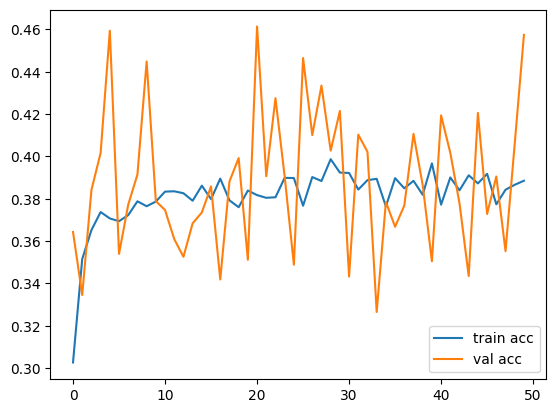

In [47]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()


Since not getting very promising results , trying with a deeper Neural network architecture : 4 hidden layered

In [49]:

model = Sequential([
    Dense(256, input_shape=(num_features,), activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

# implementing early stopping
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',   # what to watch (can also be 'val_accuracy')
    patience=10,          # how many epochs with no improvement before stopping
    restore_best_weights=True,  # roll back to the best model
    verbose=1
)


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train_zero,           # features and labels
    validation_data=(X_val, y_val_zero),  # optional but important
    epochs=150,                       # number of passes through data
    batch_size=32,                   # samples per gradient update
    class_weight=class_weight,          # handle imbalance (optional)
    verbose=1,                           # show progress 
    callbacks = [early_stop]
)

Epoch 1/150
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.2899 - loss: 1.6680 - val_accuracy: 0.3371 - val_loss: 1.5045
Epoch 2/150
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3456 - loss: 1.5526 - val_accuracy: 0.3718 - val_loss: 1.4731
Epoch 3/150
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3753 - loss: 1.5421 - val_accuracy: 0.3692 - val_loss: 1.4801
Epoch 4/150
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.3815 - loss: 1.5377 - val_accuracy: 0.4151 - val_loss: 1.4253
Epoch 5/150
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3836 - loss: 1.5371 - val_accuracy: 0.3676 - val_loss: 1.4693
Epoch 6/150
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3783 - loss: 1.5349 - val_accuracy: 0.4569 - val_loss: 1.4400
Epoch 7/150
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4008 - loss: 1.5333 - val_accuracy: 0.4337 - val_loss: 1.4214
Epoch 8/150
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3826 - loss: 1

In [50]:
evaluate_dl_model(model , X_train , y_train_zero , X_val , y_val_zero)

Training accuracy: 0.4023
Validation accuracy: 0.4073
Training precision: 0.6524203421822409
Validation precision: 0.6548459929749314
Training recall: 0.40231356857038925
Validation recall: 0.4072866953788849
Training F1-score: 0.46501055443857986
Validation F1-score: 0.47045851008064726
Training confusion matrix:
[[ 4164   924   716  2325   860]
 [  277   157    93   397   132]
 [  412   250   217   783   393]
 [  899   755   722  4020  2546]
 [ 4126  2991  2941 18534 19091]]
Validation confusion matrix:
[[ 549  116   97  279   97]
 [  30   14   19   44   16]
 [  56   27   35   77   48]
 [ 127   97   87  477  330]
 [ 550  364  346 2285 2424]]
Training classification report:
              precision    recall  f1-score   support

           0       0.42      0.46      0.44      8989
           1       0.03      0.15      0.05      1056
           2       0.05      0.11      0.06      2055
           3       0.15      0.45      0.23      8942
           4       0.83      0.40      0.54  

The model metric did not improved , rather it deteriorated:


Training F1-score: 0.46501055443857986
Validation F1-score: 0.47045851008064726

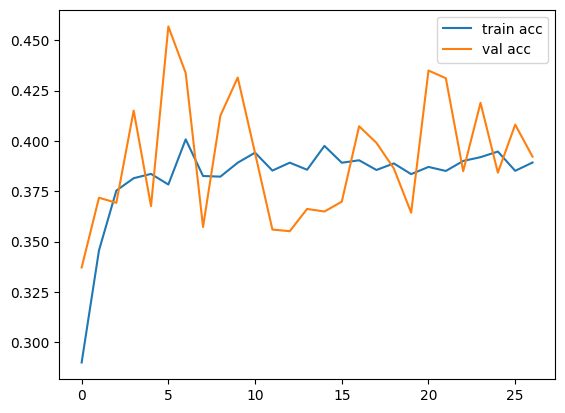

In [51]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [ ]:
# training the model using balanced data from smote tomek technique


num_features = X_train_smote_tomek.shape[1]
num_classes = np.unique(y_train_smote_tomek).size

model1 = Sequential([
    Dense(256, input_shape=(num_features,), activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

# implementing early stopping
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',   # what to watch (can also be 'val_accuracy')
    patience=10,          # how many epochs with no improvement before stopping
    restore_best_weights=True,  # roll back to the best model
    verbose=1
)


model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model1.fit(
    X_train_smote_tomek, y_train_smote_tomek - 1,           # features and labels
    validation_data=(X_val, y_val - 1),  # optional but important
    epochs=150,                       # number of passes through data
    batch_size=32,                   # samples per gradient update
    # class_weight=class_weight,          # handle imbalance (optional)
    verbose=1,                           # show progress 
    callbacks = [early_stop]
)

Epoch 1/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.2222 - loss: 1.6220 - val_accuracy: 0.1258 - val_loss: 1.9241
Epoch 2/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.2402 - loss: 1.5906 - val_accuracy: 0.6704 - val_loss: 4.3567
Epoch 3/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.2526 - loss: 1.5818 - val_accuracy: 0.6929 - val_loss: 16.3321
Epoch 4/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.2530 - loss: 1.5789 - val_accuracy: 0.6947 - val_loss: 10.6844
Epoch 5/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.2572 - loss: 1.5767 - val_accuracy: 0.7053 - val_loss: 5.6655
Epoch 6/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.2568 - loss: 1.5766 - val_accuracy: 0.6946 - val_loss: 3.1804
Epoch 7/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.2580 - loss: 1.5752 - val_accuracy: 0.6818 - val_loss: 1.2946
Epoch 8/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.2612

In [13]:
evaluate_dl_model(model1 , X_train_smote_tomek , y_train_smote_tomek - 1 , X_val , y_val - 1)

Training accuracy: 0.2659
Validation accuracy: 0.6818
Training precision: 0.2597374382241845
Validation precision: 0.5232712996765514
Training recall: 0.2659122403974089
Validation recall: 0.6817599813758585
Training F1-score: 0.24327237778875968
Validation F1-score: 0.575580154530794
Training confusion matrix:
[[15947  3551  5726  6940 11191]
 [10551  3631  7285  7829 15275]
 [ 8140  3502  7309  7997 16758]
 [ 4641  2029  7076  7328 21760]
 [ 4321  1700  6423  6754 23543]]
Validation confusion matrix:
[[   2    5   12  134  985]
 [   0    0    1    9  113]
 [   0    0    2    7  234]
 [   2    4    1   27 1084]
 [  11   15   12  105 5826]]
Training classification report:
              precision    recall  f1-score   support

           0       0.37      0.37      0.37     43355
           1       0.25      0.08      0.12     44571
           2       0.22      0.17      0.19     43706
           3       0.20      0.17      0.18     42834
           4       0.27      0.55      0.36     

Not good enough performance . I think we need to convert the multiclass classification problem into binary problem with only 2 cases : Positive Customer satisfaction and Negative Customer satisfaction.

In [14]:
# training the model using balanced data from smote tomek technique


num_features = X_train_smote_tomek.shape[1]
num_classes = np.unique(y_train_smote_tomek).size

model2 = Sequential([
    Dense(256, input_shape=(num_features,), activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

# implementing early stopping
# from tensorflow.keras.callbacks import EarlyStopping

# # Define early stopping
# early_stop = EarlyStopping(
#     monitor='val_loss',   # what to watch (can also be 'val_accuracy')
#     patience=10,          # how many epochs with no improvement before stopping
#     restore_best_weights=True,  # roll back to the best model
#     verbose=1
# )


model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model2.fit(
    X_train_smote_tomek, y_train_smote_tomek - 1,           # features and labels
    validation_data=(X_val, y_val - 1),  # optional but important
    epochs=150,                       # number of passes through data
    batch_size=32,                   # samples per gradient update
    # class_weight=class_weight,          # handle imbalance (optional)
    verbose=1,                           # show progress 
    # callbacks = [early_stop]
)

Epoch 1/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.2224 - loss: 1.6234 - val_accuracy: 0.6213 - val_loss: 1.4309
Epoch 2/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.2460 - loss: 1.5861 - val_accuracy: 0.1396 - val_loss: 13.4029
Epoch 3/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.2523 - loss: 1.5794 - val_accuracy: 0.6942 - val_loss: 11.4859
Epoch 4/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.2575 - loss: 1.5765 - val_accuracy: 0.7050 - val_loss: 7.3629
Epoch 5/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.2552 - loss: 1.5764 - val_accuracy: 0.6894 - val_loss: 9.5337
Epoch 6/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.2549 - loss: 1.5783 - val_accuracy: 0.6953 - val_loss: 7.8312
Epoch 7/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.2591 - loss: 1.5745 - val_accuracy: 0.6860 - val_loss: 2.5753
Epoch 8/150
6788/6788 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.2610

KeyboardInterrupt: 

In [18]:
# from sklearn.utils.class_weight import compute_class_weight


# unique classes in y_train_zero
classes = np.unique(y_train - 1)

# compute class weights
weights = compute_class_weight(
    class_weight='balanced',   # makes weight inversely proportional to frequency
    classes=classes,
    y=y_train - 1
)

# convert to dict {class_index: weight}
class_weight = dict(zip(classes, weights))
class_weight = {int(k): float(np.round(v,2)) for k, v in class_weight.items()}

print("Class Weights:", class_weight)


Class Weights: {0: 1.53, 1: 13.02, 2: 6.69, 3: 1.54, 4: 0.29}


In [19]:
# Without Early stopping : On original data X_train , y_train


model4 = Sequential([
    Dense(256, input_shape=(num_features,), activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])




model4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model4.fit(
    X_train, y_train - 1,           # features and labels
    validation_data=(X_val, y_val - 1),  # optional but important
    epochs=50,                       # number of passes through data
    batch_size=32,                   # samples per gradient update
    class_weight=class_weight,          # handle imbalance (optional)
    verbose=1,                           # show progress 
)

Epoch 1/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.2904 - loss: 1.6792 - val_accuracy: 0.4300 - val_loss: 1.4773
Epoch 2/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.3417 - loss: 1.5562 - val_accuracy: 0.3884 - val_loss: 1.4652
Epoch 3/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.3690 - loss: 1.5420 - val_accuracy: 0.4395 - val_loss: 1.4363
Epoch 4/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.3778 - loss: 1.5389 - val_accuracy: 0.3825 - val_loss: 1.4749
Epoch 5/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.3702 - loss: 1.5380 - val_accuracy: 0.3936 - val_loss: 1.4431
Epoch 6/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3753 - loss: 1.5362 - val_accuracy: 0.3542 - val_loss: 1.4917
Epoch 7/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3868 - loss: 1.5363 - val_accuracy: 0.4400 - val_loss: 1.4664
Epoch 8/50
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4031 - loss: 1.5355 - 